In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

In [2]:
data = pd.read_excel(r"C:\Users\Sanika\Downloads\winequality-red.csv.xlsx")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [3]:
print(data.head())

   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  
0      9.4        5  
1      9.8        5  
2      9.8        5 

In [4]:
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

Rows: 1599
Columns: 12


In [5]:
print(data.columns)

Index(['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar',
       'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density',
       'pH', 'sulphates', 'alcohol', 'quality'],
      dtype='object')


In [6]:
print(data.isnull().sum())

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [7]:
X = data.drop("quality", axis=1)

print("Input data shape:", X.shape)

Input data shape: (1599, 11)


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Data standardized successfully!")

Data standardized successfully!


In [9]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

print("Original dimensions:", X.shape[1])
print("Reduced dimensions:", X_pca.shape[1])

Original dimensions: 11
Reduced dimensions: 2


In [10]:
pca_data = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

print(pca_data.head())

        PC1       PC2
0 -1.619530  0.450950
1 -0.799170  1.856553
2 -0.748479  0.882039
3  2.357673 -0.269976
4 -1.619530  0.450950


In [11]:
print("Explained Variance Ratio:")
print(pca.explained_variance_ratio_)

Explained Variance Ratio:
[0.28173931 0.1750827 ]


In [12]:
total_variance = pca.explained_variance_ratio_.sum()

print("Total variance retained:", total_variance)
print("Total variance retained (%):", total_variance * 100)

Total variance retained: 0.45682201184294113
Total variance retained (%): 45.682201184294115


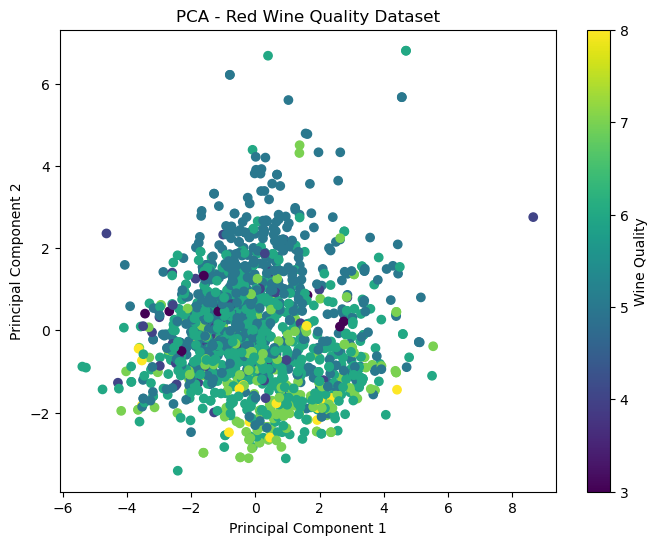

In [13]:
plt.figure(figsize=(8, 6))

plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=data["quality"]
)

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("PCA - Red Wine Quality Dataset")

plt.colorbar(label="Wine Quality")

plt.show()

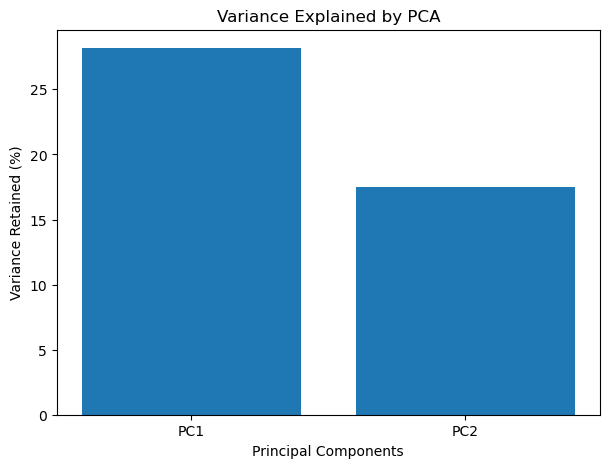

In [14]:
variance = pca.explained_variance_ratio_ * 100

plt.figure(figsize=(7, 5))

plt.bar(["PC1", "PC2"], variance)

plt.xlabel("Principal Components")
plt.ylabel("Variance Retained (%)")
plt.title("Variance Explained by PCA")

plt.show()